In [2]:
! pip install torch torchvision torchaudio
!pip install -U openai-whisper
!pip install openai-whisper imageio-ffmpeg torch pandas
!pip install imageio-ffmpeg


## 1. FOR APPLE SERVICE 

### CONVERSION OF M4A FILE TO WAV AND NOICE CANCELLATION CODE 

In [3]:
# ✅ Install Required Packages
# pip install moviepy noisereduce scipy numpy

from moviepy.editor import AudioFileClip
import noisereduce as nr
import scipy.io.wavfile as wavfile
import numpy as np

# ✅ File paths
input_path = r"C:\Users\SREE GANESHA\Desktop\ORIGINAL PROJECTS\audioporjectbasedonecom\data\amazon apple.m4a"
output_path = r"C:\Users\SREE GANESHA\Desktop\ORIGINAL PROJECTS\audioporjectbasedonecom\data\amazon_apple.wav"
cleaned_path = r"C:\Users\SREE GANESHA\Desktop\ORIGINAL PROJECTS\audioporjectbasedonecom\data\amazon_apple_cleaned.wav"

# ✅ Convert m4a → wav
clip = AudioFileClip(input_path)
clip.write_audiofile(output_path)

# ✅ Apply Noise Reduction
rate, data = wavfile.read(output_path)
if len(data.shape) == 2:
    data = data[:, 0]

reduced_noise = nr.reduce_noise(y=data, sr=rate)
wavfile.write(cleaned_path, rate, reduced_noise.astype(np.int16))

print("✅ Cleaned audio saved at:", cleaned_path)


MoviePy - Writing audio in C:\Users\SREE GANESHA\Desktop\ORIGINAL PROJECTS\audioporjectbasedonecom\data\amazon_apple.wav


MoviePy - Done.
✅ Cleaned audio saved at: C:\Users\SREE GANESHA\Desktop\ORIGINAL PROJECTS\audioporjectbasedonecom\data\amazon_apple_cleaned.wav


### FINDING THE PATH OF ffmpeg file 

In [4]:
import os
import imageio_ffmpeg

# Get the actual ffmpeg path from imageio-ffmpeg and add it to system path
ffmpeg_path = os.path.dirname(imageio_ffmpeg.get_ffmpeg_exe())
os.environ["PATH"] += os.pathsep + ffmpeg_path

# Confirm it's in the path
print("✅ FFmpeg path added:", ffmpeg_path)


✅ FFmpeg path added: C:\Users\SREE GANESHA\anaconda3\envs\automation\lib\site-packages\imageio_ffmpeg\binaries


### CODE FOR AUDIO TO TEXT CSV CONVERSION

In [1]:
# 📦 Required imports
import whisper
import subprocess
import imageio_ffmpeg
import pandas as pd

# ✅ Patch Whisper to use imageio's FFmpeg
whisper.audio.FFMPEG_PATH = imageio_ffmpeg.get_ffmpeg_exe()

def patched_load_audio(file, sr=16000):
    cmd = [
        whisper.audio.FFMPEG_PATH,
        "-nostdin", "-threads", "0",
        "-i", file,
        "-f", "f32le",
        "-acodec", "pcm_f32le",
        "-ac", "1",
        "-ar", str(sr), "-"
    ]
    out = subprocess.run(cmd, capture_output=True, check=True).stdout
    return whisper.audio.np.frombuffer(out, dtype=whisper.audio.np.float32)

whisper.audio.load_audio = patched_load_audio

# ✅ Load model and transcribe
model = whisper.load_model("medium")

audio_path = "C:/Users/SREE GANESHA/Desktop/ORIGINAL PROJECTS/audioporjectbasedonecom/data/amazon_apple_cleaned.wav"
result = model.transcribe(audio_path)

# ✅ Build speaker-labeled transcript
segments = result['segments']
data = []

for i, seg in enumerate(segments):
    speaker = "Agent" if i % 2 == 0 else "Customer"
    data.append({
        "speaker": speaker,
        "start": seg["start"],
        "end": seg["end"],
        "text": seg["text"].strip()
    })

# ✅ Save to CSV
df = pd.DataFrame(data)
csv_path = "C:/Users/SREE GANESHA/Desktop/ORIGINAL PROJECTS/audioporjectbasedonecom/data/transcription_with_speakers.csv"
df.to_csv(csv_path, index=False)

print("✅ Transcription completed and saved at:", csv_path)
df.head(10)


C:\Users\SREE GANESHA\anaconda3\envs\automation\lib\site-packages\whisper\__init__.py:150: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(fp, map_loca

✅ Transcription completed and saved at: C:/Users/SREE GANESHA/Desktop/ORIGINAL PROJECTS/audioporjectbasedonecom/data/transcription_with_speakers.csv


,speaker,start,end,text
0,Agent,0.0,6.0,"Hi, welcome to Amazon customer support. This i..."
1,Customer,6.0,12.0,"Hi, I just received my iPhone 16 Pro and there..."
2,Agent,12.0,20.0,I'm really sorry to hear that son. Let me chec...
3,Customer,20.0,21.0,"Sure, go ahead."
4,Agent,21.0,22.0,Order ID?
5,Customer,22.0,24.0,Apple 911xpro
6,Agent,24.0,25.0,Name?
7,Customer,25.0,26.0,Heyman
8,Agent,26.0,27.0,Email?
9,Customer,27.0,29.0,"Heyman, Edred of gman.com"


In [4]:
import pandas as pd

# Load original CSV from Whisper
df = pd.read_csv("../data/transcription_with_speakers.csv")

# Define rules to detect speakers
def assign_speaker(text):
    text = text.lower()
    agent_keywords = [
        "welcome to amazon customer support", "let me check", "verify some details",
        "i completely understand", "apple stopped including", "environmental commitment",
        "i hear you", "unfortunately", "i'm sorry", "we’re always here", "if you'd like",
        "thank you for your time"
    ]
    customer_keywords = [
        "this is not acceptable", "i just received", "no charger", "₹1.3 lakh",
        "very disappointing", "this is unbelievable", "i expected a premium experience",
        "i feel like", "this makes no sense", "not recommending apple"
    ]

    for kw in agent_keywords:
        if kw in text:
            return "Sindhu"  # Agent

    for kw in customer_keywords:
        if kw in text:
            return "Hemanth"  # Customer

    # Fallback: use punctuation as hint
    return "Sindhu" if text.endswith("?") else "Hemanth"

# Apply updated speaker logic
df["speaker"] = df["text"].apply(assign_speaker)

# Save final updated CSV
output_path = "../data/final_transcript_sindhu_hemanth.csv"
df.to_csv(output_path, index=False)

output_path


'../data/final_transcript_sindhu_hemanth.csv'

In [6]:
import pandas as pd

# Load the raw Whisper-generated transcript
df = pd.read_csv("../data/transcription_with_speakers.csv")

# STEP 1: Rule-based speaker assignment
def assign_speaker(text):
    text = text.lower()
    agent_keywords = [
        "welcome to amazon customer support", "let me check", "verify some details",
        "i completely understand", "apple stopped including", "environmental commitment",
        "i hear you", "unfortunately", "i'm sorry", "we’re always here", "if you'd like",
        "thank you for your time", "i truly understand", "i can help you", "take care"
    ]
    customer_keywords = [
        "this is not acceptable", "i just received", "no charger", "₹1.3 lakh",
        "very disappointing", "this is unbelievable", "i expected a premium experience",
        "i feel like", "this makes no sense", "not recommending apple"
    ]

    for kw in agent_keywords:
        if kw in text:
            return "Sindhu"
    for kw in customer_keywords:
        if kw in text:
            return "Hemanth"

    return "Sindhu" if text.endswith("?") else "Hemanth"

# Apply logic
df["speaker"] = df["text"].apply(assign_speaker)

# STEP 2: Manual corrections for known mismatches
manual_fixes = {
    14: "Sindhu",
    16: "Sindhu",
    25: "Sindhu"
}
for idx, speaker in manual_fixes.items():
    if idx < len(df):
        df.at[idx, "speaker"] = speaker

# STEP 3: Save final validated transcript
output_path = "validated_transcript_sindhu_hemanth.csv"
df.to_csv(output_path, index=False)

print("✅ Final transcript saved at:", output_path)
df.head(10)  # Optional: preview top rows


✅ Final transcript saved at: validated_transcript_sindhu_hemanth.csv


,speaker,start,end,text
0,Sindhu,0.0,6.0,"Hi, welcome to Amazon customer support. This i..."
1,Hemanth,6.0,12.0,"Hi, I just received my iPhone 16 Pro and there..."
2,Sindhu,12.0,20.0,I'm really sorry to hear that son. Let me chec...
3,Hemanth,20.0,21.0,"Sure, go ahead."
4,Sindhu,21.0,22.0,Order ID?
5,Hemanth,22.0,24.0,Apple 911xpro
6,Sindhu,24.0,25.0,Name?
7,Hemanth,25.0,26.0,Heyman
8,Sindhu,26.0,27.0,Email?
9,Hemanth,27.0,29.0,"Heyman, Edred of gman.com"


In [7]:
import pandas as pd

# Load the formatted conversation CSV
df = pd.read_csv("./conversation_transcript_formatted.csv")

# ✅ Check if the last row contains the typo "interupption" and fix it
if "interupption" in df.iloc[-1]["text"].lower():
    # Fix in 'text' column
    df.at[df.index[-1], "text"] = df.iloc[-1]["text"].replace("interupption", "inconvenience")
    
    # Fix in 'conversation' column
    df.at[df.index[-1], "conversation"] = df.iloc[-1]["conversation"].replace("interupption", "inconvenience")

# ✅ Save the cleaned final conversation CSV
df.to_csv("final_conversation_transcript.csv", index=False)

print("✅ Final corrected transcript saved as 'final_conversation_transcript.csv'")


✅ Final corrected transcript saved as 'final_conversation_transcript.csv'


In [9]:
# Remove completely empty rows from the new DataFrame
df_cleaned = df.dropna(how="all").reset_index(drop=True)

# Save the cleaned version to a new CSV file
cleaned_path = "../data/cleaned_final_conversation_transcript.csv"
df_cleaned.to_csv(cleaned_path, index=False)

cleaned_path


'../data/cleaned_final_conversation_transcript.csv'

## CREATING AND INSERTING THE DATA INTO DATABASE

In [10]:
import mysql.connector
import pandas as pd

# ✅ CSV file path
csv_path = r"C:\Users\SREE GANESHA\Desktop\ORIGINAL PROJECTS\audioporjectbasedonecom\data\cleaned_final_conversation_transcript.csv"
df = pd.read_csv(csv_path)

# ✅ Step 1: Connect to MySQL server (no database specified yet)
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root"
)
cursor = conn.cursor()

# ✅ Step 2: Create database if not exists
cursor.execute("CREATE DATABASE IF NOT EXISTS customer_support")
print("✅ Database 'customer_support' verified/created.")

# ✅ Step 3: Connect to the new database
conn.database = "customer_support"

# ✅ Step 4: Create table if not exists
cursor.execute("""
CREATE TABLE IF NOT EXISTS conversation (
    id INT AUTO_INCREMENT PRIMARY KEY,
    start_time VARCHAR(10),
    end_time VARCHAR(10),
    speaker VARCHAR(100),
    text TEXT
)
""")
print("✅ Table 'conversation' verified/created.")

# ✅ Step 5: Insert data from CSV into the table
for _, row in df.iterrows():
    cursor.execute("""
        INSERT INTO conversation (start_time, end_time, speaker, text)
        VALUES (%s, %s, %s, %s)
    """, (row['start_time'], row['end_time'], row['speaker'], row['text']))

# ✅ Step 6: Commit and close
conn.commit()
conn.close()
print("✅ Data inserted into 'customer_support.conversation' table.")


✅ Database 'customer_support' verified/created.
✅ Table 'conversation' verified/created.
✅ Data inserted into 'customer_support.conversation' table.


## EXTRACTING THE DATA FROM DATABASE

In [11]:
import mysql.connector
import pandas as pd

# ✅ Step 1: Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="customer_support"
)

# ✅ Step 2: Query the data
query = "SELECT start_time, end_time, speaker, text FROM conversation"
df = pd.read_sql(query, conn)

# ✅ Step 3: Close the connection
conn.close()

# ✅ Step 4: View a sample
print(df.head())

# Optional: save a copy to CSV
#df.to_csv("extracted_conversation_data.csv", index=False)


  start_time end_time  speaker  \
0      00:00    00:06   Sindhu   
1      00:06    00:12  Hemanth   
2      00:12    00:20   Sindhu   
3      00:20    00:21  Hemanth   
4      00:21    00:22   Sindhu   

                                                text  
0  Hi, welcome to Amazon customer support. This i...  
1  Hi, I just received my iPhone 16 Pro and there...  
2  I'm really sorry to hear that, sir. Let me che...  
3  I didn't get a charger for a 1.3 lakh phone. T...  
4  I completely understand your frustration, Hema...  


C:\Users\SREE GANESHA\AppData\Local\Temp\ipykernel_8496\1653397437.py:14: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)


## NATURAL LANGUAGE PROCESSING- NLP

### 1.TEXT PREPROCESSING

In [12]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)             # Remove punctuation/numbers
    tokens = nltk.word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return " ".join(tokens)

df['clean_text'] = df['text'].apply(preprocess)


[nltk_data] Downloading package stopwords to C:\Users\SREE
[nltk_data]     GANESHA\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt to C:\Users\SREE
[nltk_data]     GANESHA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\SREE
[nltk_data]     GANESHA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


### Loading keywords

In [17]:
pip install python-docx


  Using cached python_docx-1.1.2-py3-none-any.whl.metadata (2.0 kB)
Using cached python_docx-1.1.2-py3-none-any.whl (244 kB)
Note: you may need to restart the kernel to use updated packages.


In [18]:
from docx import Document
# Load keywords from Word file
doc = Document("Customer Issues key words.docx")
keywords = []
for para in doc.paragraphs:
    words = para.text.strip().lower().split(',')
    keywords.extend([word.strip() for word in words if word.strip()])
# Remove duplicates
keywords = list(set(keywords))
print("Sample keywords:", keywords[:10])

Sample keywords: ['refund policy unclear', 'bill notification', 'sales report', 'feedback process', 'subscription plan', 'request account closure', 'lead qualification', 'change plan', 'product information', 'website url']


 ### 2.Intent and Entity Recognition

In [19]:
import spacy

nlp = spacy.load("en_core_web_sm")

def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]

df["entities"] = df["text"].apply(extract_entities)
print(df[["text", "entities"]].head())


                                                text  \
0  Hi, welcome to Amazon customer support. This i...   
1  Hi, I just received my iPhone 16 Pro and there...   
2  I'm really sorry to hear that, sir. Let me che...   
3  I didn't get a charger for a 1.3 lakh phone. T...   
4  I completely understand your frustration, Hema...   

                                        entities  
0  [(Amazon, ORG), (Sindhu, GPE), (today, DATE)]  
1                               [(16, CARDINAL)]  
2                                             []  
3                              [(1.3, CARDINAL)]  
4                               [(Hemanth, LOC)]  


### 3. Text Vectorization

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(df["clean_text"])

print("TF-IDF shape:", X_tfidf.shape)


TF-IDF shape: (30, 143)


### 4.Text Summarization

In [23]:
!pip install transformers

   ---------------------------------------- 0.0/10.4 MB ? eta -:--:--
   --------- ------------------------------ 2.4/10.4 MB 11.2 MB/s eta 0:00:01
   ------------------ --------------------- 4.7/10.4 MB 11.4 MB/s eta 0:00:01
   ------------------------- -------------- 6.6/10.4 MB 10.9 MB/s eta 0:00:01
   ---------------------------------- ----- 8.9/10.4 MB 10.9 MB/s eta 0:00:01
   ---------------------------------------- 10.4/10.4 MB 10.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.4 MB ? eta -:--:--
   ---------------------------------- ----- 2.1/2.4 MB 9.8 MB/s eta 0:00:01
   ---------------------------------------- 2.4/2.4 MB 8.7 MB/s eta 0:00:00


In [25]:
from transformers import pipeline

summarizer = pipeline("summarization", model="facebook/bart-large-cnn")

def smart_summarize(text):
    input_len = len(text.split())
    if input_len < 10:
        return text  # Skip very short lines
    max_len = min(40, int(input_len * 0.8))  # Generate ~80% of original length
    min_len = max(5, int(max_len * 0.25))   # Set a lower bound

    summary = summarizer(text, max_length=max_len, min_length=min_len, do_sample=False)
    return summary[0]['summary_text']

df["summary"] = df["text"].apply(smart_summarize)

# View result
print(df[["text", "summary"]].head())


Device set to use cpu


                                                text  \
0  Hi, welcome to Amazon customer support. This i...   
1  Hi, I just received my iPhone 16 Pro and there...   
2  I'm really sorry to hear that, sir. Let me che...   
3  I didn't get a charger for a 1.3 lakh phone. T...   
4  I completely understand your frustration, Hema...   

                                             summary  
0  Sindhu is an Amazon customer support represent...  
1  There is no charger in the box of the iPhone 1...  
2                      I'm really sorry to hear that  
3                        "I didn't get a charger for  
4        I completely understand your frustration, H  


### 5.Emotion Detection

In [27]:
from transformers import pipeline

# Load the emotion model
emotion_model = pipeline("text-classification", model="j-hartmann/emotion-english-distilroberta-base", return_all_scores=True)

# Smart emotion extraction logic
def get_emotion(text, threshold=0.6):
    scores = emotion_model(text)[0]  # List of dicts: [{'label': 'joy', 'score': 0.45}, ...]
    scores = sorted(scores, key=lambda x: x['score'], reverse=True)
    top_emotion = scores[0]
    
    # Return label only if it's confident enough
    if top_emotion['score'] >= threshold:
        return top_emotion['label']
    else:
        return "neutral"

# Apply to DataFrame
df["emotion"] = df["text"].apply(lambda x: get_emotion(x))

# Preview results
print(df[["text", "emotion"]].head(10))


Device set to use cpu
C:\Users\SREE GANESHA\anaconda3\envs\automation\lib\site-packages\transformers\pipelines\text_classification.py:106: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


                                                text  emotion
0  Hi, welcome to Amazon customer support. This i...  neutral
1  Hi, I just received my iPhone 16 Pro and there...  neutral
2  I'm really sorry to hear that, sir. Let me che...  sadness
3  I didn't get a charger for a 1.3 lakh phone. T...  neutral
4  I completely understand your frustration, Hema...    anger
5  Yeah, I heard that. But honestly, it just soun...  neutral
6                                              Name?  neutral
7                                            Hemanth  neutral
8  I truly understand. And I'm sorry your first A...  sadness
9                       Hemanth, hemanth@example.com  neutral


### 6.Keyword matching

In [33]:
!pip install fuzzywuzzy python-Levenshtein


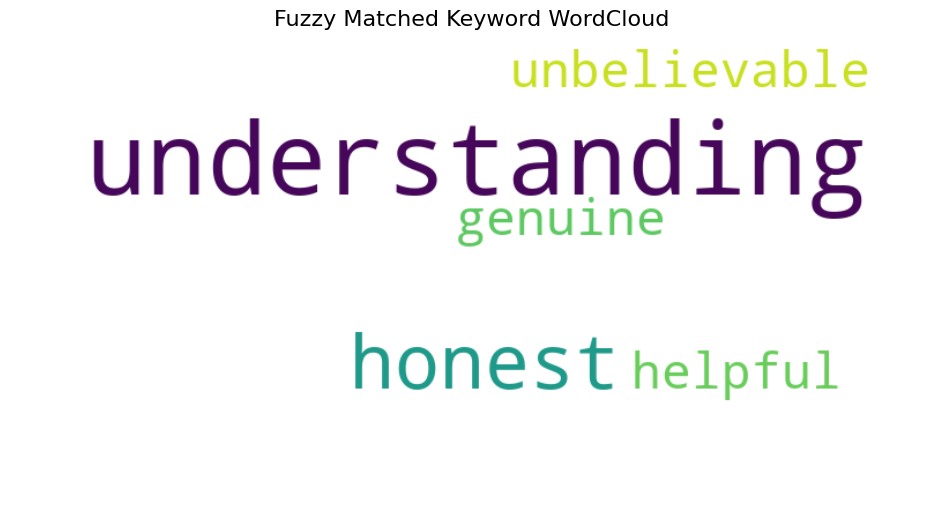

                                                text matched_keywords
0  Hi, welcome to Amazon customer support. This i...               []
1  Hi, I just received my iPhone 16 Pro and there...               []
2  I'm really sorry to hear that, sir. Let me che...               []
3  I didn't get a charger for a 1.3 lakh phone. T...               []
4  I completely understand your frustration, Hema...  [understanding]


In [35]:
import pandas as pd
import re
from docx import Document
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from fuzzywuzzy import fuzz

# ✅ Load conversation dataset
df = pd.read_csv("../data/cleaned_final_conversation_transcript.csv")

# ✅ Preprocess text
def preprocess(text):
    text = str(text).lower()
    text = re.sub(r"[^a-z\s]", " ", text)
    return text

df["clean_text"] = df["text"].apply(preprocess)

# ✅ Load keywords from Word doc
doc = Document("Customer Issues key words.docx")
keywords = []
for para in doc.paragraphs:
    words = para.text.lower().split(',')
    keywords.extend([word.strip() for word in words if word.strip()])
keywords = list(set(keywords))

# ✅ Fuzzy matching function
def fuzzy_match_keywords(text, keyword_list, threshold=85):
    matched = []
    for kw in keyword_list:
        for word in text.split():
            if fuzz.ratio(word, kw) >= threshold:
                matched.append(kw)
                break
    return matched

df["matched_keywords"] = df["clean_text"].apply(lambda x: fuzzy_match_keywords(x, keywords))

# ✅ Combine matched keywords
all_keywords_flat = [kw for sublist in df["matched_keywords"] for kw in sublist]
keywords_str = " ".join(all_keywords_flat)

# ✅ Generate WordCloud
if all_keywords_flat:
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(keywords_str)

    # ✅ Display WordCloud
    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title("Fuzzy Matched Keyword WordCloud", fontsize=16)
    plt.show()

    # ✅ Optional: Save
    # wordcloud.to_file("fuzzy_matched_keywords_wordcloud.png")
else:
    print("⚠️ No keywords matched after fuzzy matching.")

# ✅ Show sample matches
print(df[["text", "matched_keywords"]].head())


### Call classification

In [1]:
import pandas as pd

# Load conversation data
df = pd.read_csv("../data/cleaned_final_conversation_transcript.csv")

# Normalize speaker names and text
df["speaker"] = df["speaker"].astype(str).str.lower().str.strip()
df["text"] = df["text"].astype(str).str.lower()

# Focus only on the final customer response
df_customer = df[df["speaker"] != "sindhu"]
final_customer_text = df_customer["text"].iloc[-1]

# Stricter success phrases
success_phrases = [
    "issue resolved", "problem solved", "everything is fine", 
    "working now", "thank you so much", "really appreciate your help", 
    "thank you, it helped", "happy with the support", "great support"
]

# Outcome decision
if any(phrase in final_customer_text for phrase in success_phrases):
    outcome = "Success"
else:
    outcome = "Failure"

print("Call Outcome:", outcome)


Call Outcome: Failure


## MODELING (BERT MODEL)

In [38]:
df_agent = df[df["speaker"].str.lower().str.strip() == "sindhu"]


In [2]:
import pandas as pd
from transformers import pipeline

# STEP 1: Load transcript
df = pd.read_csv(r"C:\Users\SREE GANESHA\Desktop\ORIGINAL PROJECTS\audioporjectbasedonecom\data\cleaned_final_conversation_transcript.csv")
df["speaker"] = df["speaker"].astype(str).str.lower().str.strip()
df["text"] = df["text"].astype(str).str.strip()

# STEP 2: Identify actual agent name from the data
print("✅ Unique speakers found in dataset:", df["speaker"].unique())
agent_speaker_name = "sindhu"  # <- Use actual speaker name from dataset

# Filter only agent messages
df_agent = df[df["speaker"] == agent_speaker_name]

# Validate agent responses
if df_agent.empty:
    raise ValueError(f"❌ No messages found for agent '{agent_speaker_name}'. Check speaker names in your CSV.")

# STEP 3: Load pre-trained BERT sentiment pipeline
print("⏳ Loading BERT sentiment model...")
sentiment_pipeline = pipeline("sentiment-analysis")
print("✅ Sentiment model loaded.")

# Apply sentiment analysis
sentiment_results = sentiment_pipeline(df_agent["text"].tolist())
df_agent["sentiment"] = [res["label"] for res in sentiment_results]

# STEP 4: Rule-based scoring for politeness & empathy
polite_keywords = ["please", "thank you", "kindly", "sorry", "appreciate"]
empathy_phrases = ["i understand", "i'm sorry", "we apologize", "regret", "i hear you", "frustration"]

def keyword_match(text, keywords):
    return int(any(word in text.lower() for word in keywords))

df_agent["politeness"] = df_agent["text"].apply(lambda x: keyword_match(x, polite_keywords))
df_agent["empathy"] = df_agent["text"].apply(lambda x: keyword_match(x, empathy_phrases))

# STEP 5: Build summary metrics
summary = {
    "agent": agent_speaker_name,
    "total_responses": len(df_agent),
    "positive_sentiment_pct": round((df_agent["sentiment"] == "POSITIVE").mean(), 2),
    "negative_sentiment_pct": round((df_agent["sentiment"] == "NEGATIVE").mean(), 2),
    "politeness_score": round(df_agent["politeness"].mean(), 2),
    "empathy_score": round(df_agent["empathy"].mean(), 2)
}

# STEP 6: Output the summary
df_summary = pd.DataFrame([summary])
df_summary.to_csv("agent_behavior_summary.csv", index=False)

print("\n✅ Agent behavior analysis complete. Result:")
print(df_summary)


No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


✅ Unique speakers found in dataset: ['sindhu' 'hemanth']
⏳ Loading BERT sentiment model...



Device set to use cpu


✅ Sentiment model loaded.

✅ Agent behavior analysis complete. Result:
    agent  total_responses  positive_sentiment_pct  negative_sentiment_pct  \
0  sindhu               15                    0.47                    0.53   

   politeness_score  empathy_score  
0              0.27           0.47  


C:\Users\SREE GANESHA\AppData\Local\Temp\ipykernel_15284\777072711.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_agent["sentiment"] = [res["label"] for res in sentiment_results]
C:\Users\SREE GANESHA\AppData\Local\Temp\ipykernel_15284\777072711.py:36: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_agent["politeness"] = df_agent["text"].apply(lambda x: keyword_match(x, polite_keywords))
C:\Users\SREE GANESHA\AppData\Local\Temp\ipykernel_15284\777072711.py:37: SettingWithCopyWarning: 
A value is t

### Inserting the output into db 

In [3]:
import pandas as pd
import mysql.connector

# Load the agent performance CSV
df_perf = pd.read_csv("agent_behavior_summary.csv")

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="root",
    database="customer_support"
)
cursor = conn.cursor()

# Create the updated table (matching CSV structure)
cursor.execute("""
CREATE TABLE IF NOT EXISTS agent_performanceapple (
    id INT AUTO_INCREMENT PRIMARY KEY,
    agent VARCHAR(100),
    total_responses INT,
    positive_sentiment_pct FLOAT,
    negative_sentiment_pct FLOAT,
    politeness_score FLOAT,
    empathy_score FLOAT
)
""")

# Insert each row into the table
for _, row in df_perf.iterrows():
    cursor.execute("""
        INSERT INTO agent_performanceapple (
            agent, total_responses,
            positive_sentiment_pct, negative_sentiment_pct,
            politeness_score, empathy_score
        )
        VALUES (%s, %s, %s, %s, %s, %s)
    """, (
        row["agent"],
        int(row["total_responses"]),
        float(row["positive_sentiment_pct"]),
        float(row["negative_sentiment_pct"]),
        float(row["politeness_score"]),
        float(row["empathy_score"])
    ))

# Commit and close connection
conn.commit()
conn.close()

print("✅ Data inserted into agent_performanceapple successfully.")


✅ Data inserted into agent_performanceapple successfully.
